# Modelo BiLSTM-CNN Att



In [1]:
# ========================== #
# 1. Librerías y Configuración Inicial
# ========================== #
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, \
    precision_score, recall_score, f1_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt
import torch.nn as nn
import gc
import stanza
import os
import numpy as np
import math
from collections import Counter
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer

# ==== Stanza y BERT ==== #
stanza.download("es", verbose=False)
nlp_stanza = stanza.Pipeline("es", processors="tokenize,pos,lemma")
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model_bert = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model_bert.to(device)
print(f"Usando dispositivo: {device}")



c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\stanza\models\tokenization\trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by

Usando dispositivo: cuda


In [2]:
# ==== Datos ==== #
DATA_PATH = r"C:\Users\Sistemas\Desktop\PFINAL\nuevo_df.csv"
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
#df = df.head(300)

if "clean_text" not in df.columns:
    txt_col = next(c for c in df.select_dtypes("object").columns if c != "Nivel_f")
    pref = os.path.commonprefix(df[txt_col].tolist())
    df["clean_text"] = df[txt_col].str[len(pref):].str.strip()

label_encoder = LabelEncoder()
df["etiqueta_codificada"] = label_encoder.fit_transform(df["Nivel_f"])

print(df[["Nivel_f", "clean_text"]].head())
print(df["Nivel_f"].value_counts())

X_text = df["clean_text"]
y = df["etiqueta_codificada"]
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)



      Nivel_f                                         clean_text
0  Medio bajo  otro aspecto que podemos tener en cuenta es la...
1  Medio alto  En segundo lugar, el aprendizaje de lectura y ...
2  Medio bajo  en segundo lugar, fomentando estas practicas d...
3  Medio bajo  En segundo lugar, la lectura y escritura es fu...
4  Medio bajo  La lectura y la escritura son importantes para...
Nivel_f
Medio alto    687
Medio bajo    644
Bajo          310
Alto          279
Name: count, dtype: int64


In [3]:
from itertools import product
dropout_grid = [0.2, 0.4]
learning_rate_grid = [2e-5, 5e-5, 1e-4]
n_splits_grid = [3]
EPOCHS = 30   # Puedes ajustar a 15 según aprendizaje observado

# ========================== #
# 2. Funciones de Features Lingüísticas y Distancias
# ========================== #
def extraer_caracteristicas_avanzadas(texto, tokenizer, model, device):
    doc = nlp_stanza(texto)
    oraciones = [s.text for s in doc.sentences]
    palabras = [w.text.lower() for s in doc.sentences for w in s.words if w.text.isalpha()]
    tipos = set(palabras)
    tokens = len(palabras)
    tipos_count = len(tipos)
    hapax = sum(1 for v in Counter(palabras).values() if v == 1)
    ttr = tipos_count / tokens if tokens else 0
    rttr = tipos_count / np.sqrt(2 * tokens) if tokens else 0
    cttr = tipos_count / np.sqrt(2 * tokens) if tokens else 0
    maas = (math.log(tokens) - math.log(tipos_count)) / (math.log(tokens)**2) if tokens > 1 and tipos_count > 1 else 0
    herdan = math.log(tipos_count) / math.log(tokens) if tokens > 1 and tipos_count > 1 else 0
    honore = 100 * math.log(tokens) / (1 - (hapax / tipos_count)) if tipos_count > 1 and (1 - (hapax / tipos_count)) != 0 else 0
    def mattr(palabras, window_size=50):
        if len(palabras) < window_size:
            return ttr
        return np.mean([len(set(palabras[i:i+window_size]))/window_size
                        for i in range(len(palabras)-window_size+1)])
    def mtld(palabras, threshold=0.72):
        factors, factor_length, ttr_temp = 0, 0, []
        for i, word in enumerate(palabras, 1):
            ttr_temp.append(word)
            if len(set(ttr_temp)) / len(ttr_temp) <= threshold:
                factors += 1
                factor_length += len(ttr_temp)
                ttr_temp = []
        if ttr_temp:
            factors += 1
            factor_length += len(ttr_temp)
        return factor_length / factors if factors else 0
    mattr_val = mattr(palabras)
    mtld_val = mtld(palabras)
    parrafos = [p for p in texto.split('\n') if p.strip()]
    n_parrafos = len(parrafos)
    n_oraciones = len(oraciones)
    oraciones_lens = [len([w for w in s.split() if w.isalpha()]) for s in oraciones]
    parrafos_lens = [len([w for w in p.split() if w.isalpha()]) for p in parrafos]
    return {
        "ttr": ttr, "rttr": rttr, "cttr": cttr, "mattr": mattr_val, "mtld": mtld_val,
        "honore": honore, "maas": maas, "herdan": herdan,
        "prom_oraciones_por_parrafo": n_oraciones / n_parrafos if n_parrafos else 0,
        "prom_longitud_oracion": np.mean(oraciones_lens) if oraciones_lens else 0,
        "desv_longitud_oracion": np.std(oraciones_lens) if oraciones_lens else 0,
        "prom_longitud_parrafo": np.mean(parrafos_lens) if parrafos_lens else 0,
        "desv_longitud_parrafo": np.std(parrafos_lens) if parrafos_lens else 0,
    }

def tokenizar_datos(textos, tokenizer, max_len=512):
    return tokenizer(
        textos,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

def obtener_embedding_promedio(texto, tokenizer, model, device):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding_texto = outputs.last_hidden_state.mean(dim=1).cpu().detach().numpy().squeeze()
    return embedding_texto

def calcular_centroides_por_clase(X_text_train, y_train, tokenizer, model, device):
    centroids = {}
    y_arr = np.array(y_train)
    for class_idx in np.unique(y_arr):
        idxs = np.where(y_arr == class_idx)[0]
        textos = X_text_train.iloc[idxs].tolist()
        embeddings = [obtener_embedding_promedio(t, tokenizer, model, device) for t in textos]
        centroids[class_idx] = np.mean(embeddings, axis=0)
    return centroids

def agregar_distancia_a_centroides(texto, tokenizer, model, device, class_centroids):
    embedding = obtener_embedding_promedio(texto, tokenizer, model, device)
    return {f"dist_centroide_{cls}": np.linalg.norm(embedding - centroid) for cls, centroid in class_centroids.items()}



In [4]:
# ========================== #
# 3. Modelos y Dataset
# ========================== #
class TextDataset(Dataset):
    def __init__(self, encodings, features, labels):
        self.encodings = encodings
        self.features = features.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['features'] = torch.tensor(self.features.iloc[idx].values, dtype=torch.float)
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

# class BiLSTM_CNN_Text_Classifier(nn.Module):
#     def __init__(self, bert_model, lstm_hidden_dim, n_filters, filter_sizes, output_dim, dropout, n_linguistic_features):
#         super().__init__()
#         self.bert = bert_model
#         embedding_dim = self.bert.config.hidden_size
#         self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, bidirectional=True, batch_first=True)
#         self.convs = nn.ModuleList([
#             nn.Conv2d(in_channels=1, out_channels=n_filters, kernel_size=(fs, 2 * lstm_hidden_dim))
#             for fs in filter_sizes
#         ])
#         self.fc1 = nn.Linear(len(filter_sizes) * n_filters + n_linguistic_features, 128)
#         self.fc2 = nn.Linear(128, output_dim)
#         self.dropout = nn.Dropout(dropout)
#     def forward(self, input_ids, attention_mask, features):
#         with torch.no_grad():
#             bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         embeddings = bert_outputs.last_hidden_state
#         lstm_out, _ = self.lstm(embeddings)
#         lstm_out = lstm_out.unsqueeze(1)
#         conved = [torch.relu(conv(lstm_out)).squeeze(3) for conv in self.convs]
#         pooled = [torch.max(conv, dim=2)[0] for conv in conved]
#         cat = self.dropout(torch.cat(pooled, dim=1))
#         cat = torch.cat((cat, features), dim=1)
#         x = self.dropout(torch.relu(self.fc1(cat)))
#         return self.fc2(x)

import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch_size, seq_len, hidden_dim)
        attn_weights = F.softmax(self.attn(lstm_output), dim=1)  # (batch_size, seq_len, 1)
        context = torch.sum(attn_weights * lstm_output, dim=1)   # (batch_size, hidden_dim)
        return context

class BiLSTM_CNN_Text_Classifier(nn.Module):
    def __init__(self, bert_model, lstm_hidden_dim, n_filters, filter_sizes, output_dim, dropout, n_linguistic_features):
        super().__init__()
        self.bert = bert_model
        embedding_dim = self.bert.config.hidden_size
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, num_layers=2, bidirectional=True, batch_first=True)
        self.attn = Attention(2 * lstm_hidden_dim)  # BiLSTM output dim
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=n_filters, kernel_size=(fs, 2 * lstm_hidden_dim))
            for fs in filter_sizes
        ])
        self.fc1 = nn.Linear(len(filter_sizes) * n_filters + 2 * lstm_hidden_dim + n_linguistic_features, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, features):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = bert_outputs.last_hidden_state    # (batch, seq_len, bert_dim)
        lstm_out, _ = self.lstm(embeddings)            # (batch, seq_len, 2*lstm_h)
        attn_vec = self.attn(lstm_out)                 # (batch, 2*lstm_h)
        lstm_out_unsq = lstm_out.unsqueeze(1)          # (batch, 1, seq_len, 2*lstm_h)
        conved = [torch.relu(conv(lstm_out_unsq)).squeeze(3) for conv in self.convs]
        pooled = [torch.max(conv, dim=2)[0] for conv in conved]
        cat_cnn = self.dropout(torch.cat(pooled, dim=1))
        # Fusionamos [CNN features | Attention | Ling features]
        cat = torch.cat((cat_cnn, attn_vec, features), dim=1)
        x = self.dropout(F.relu(self.bn1(self.fc1(cat))))
        return self.fc2(x)





>>> Entrenando con dropout=0.2, lr=2e-05, folds=3

--- Procesando Fold 1/3 ---
Grid 0.2-2e-05-3, Fold 1, Epoch 1 | Train Acc: 0.273 | Val Acc: 0.152 | MacroF1: 0.111
Grid 0.2-2e-05-3, Fold 1, Epoch 2 | Train Acc: 0.275 | Val Acc: 0.209 | MacroF1: 0.205
Grid 0.2-2e-05-3, Fold 1, Epoch 3 | Train Acc: 0.274 | Val Acc: 0.258 | MacroF1: 0.264
Grid 0.2-2e-05-3, Fold 1, Epoch 4 | Train Acc: 0.317 | Val Acc: 0.277 | MacroF1: 0.281
Grid 0.2-2e-05-3, Fold 1, Epoch 5 | Train Acc: 0.337 | Val Acc: 0.289 | MacroF1: 0.293
Grid 0.2-2e-05-3, Fold 1, Epoch 6 | Train Acc: 0.330 | Val Acc: 0.299 | MacroF1: 0.303
Grid 0.2-2e-05-3, Fold 1, Epoch 7 | Train Acc: 0.344 | Val Acc: 0.309 | MacroF1: 0.311
Grid 0.2-2e-05-3, Fold 1, Epoch 8 | Train Acc: 0.347 | Val Acc: 0.312 | MacroF1: 0.315
Grid 0.2-2e-05-3, Fold 1, Epoch 9 | Train Acc: 0.374 | Val Acc: 0.312 | MacroF1: 0.315
Grid 0.2-2e-05-3, Fold 1, Epoch 10 | Train Acc: 0.390 | Val Acc: 0.328 | MacroF1: 0.332
Grid 0.2-2e-05-3, Fold 1, Epoch 11 | Train Acc: 0

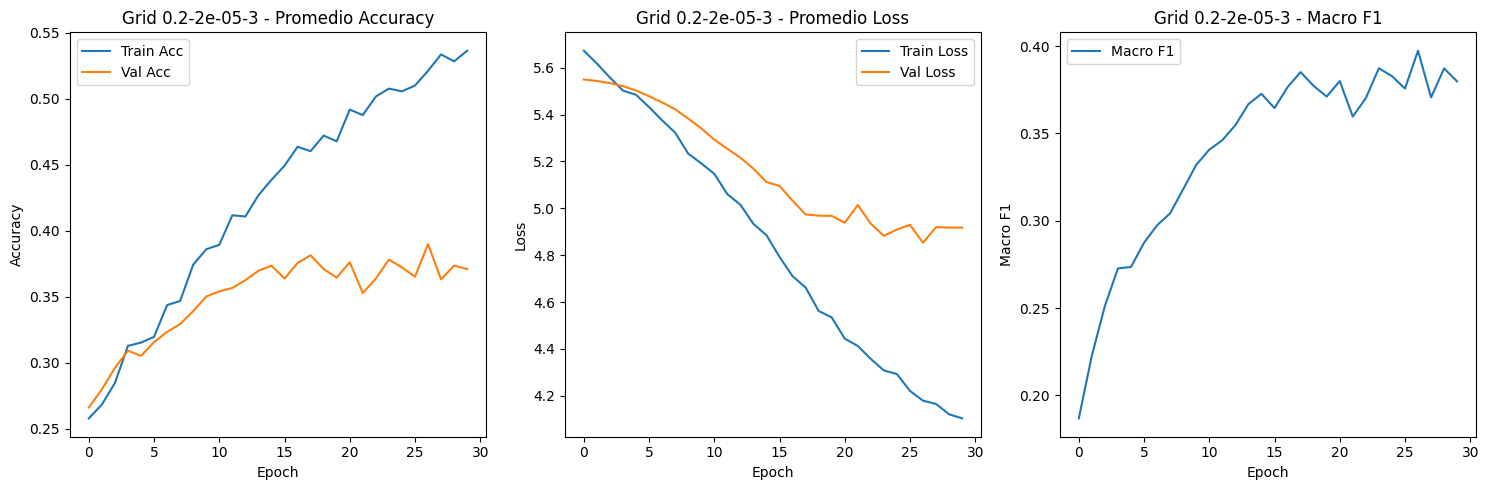


Métricas en validación (media y std):
accuracy     0.371094
precision    0.430375
recall       0.476677
f1           0.379744
dtype: float64
accuracy     0.005859
precision    0.020663
recall       0.017097
f1           0.011819
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)

>>> Entrenando con dropout=0.2, lr=5e-05, folds=3

--- Procesando Fold 1/3 ---
Grid 0.2-5e-05-3, Fold 1, Epoch 1 | Train Acc: 0.268 | Val Acc: 0.150 | MacroF1: 0.107
Grid 0.2-5e-05-3, Fold 1, Epoch 2 | Train Acc: 0.277 | Val Acc: 0.207 | MacroF1: 0.182
Grid 0.2-5e-05-3, Fold 1, Epoch 3 | Train Acc: 0.302 | Val Acc: 0.256 | MacroF1: 0.235
Grid 0.2-5e-05-3, Fold 1, Epoch 4 | Train Acc: 0.330 | Val Acc: 0.293 | MacroF1: 0.283
Grid 0.2-5e-05-3, Fold 1, Epoch 5 | Train Acc: 0.373 | Val Acc: 0.297 | MacroF1: 0.307
Grid 0.2-5e-05-3, Fold 1, Epoch 6 | Train Acc: 0.394 | Val Acc: 0.324 | MacroF1: 0.339
Grid 0.2-5e-05-3, Fold 1, Epoch 7 | Tr

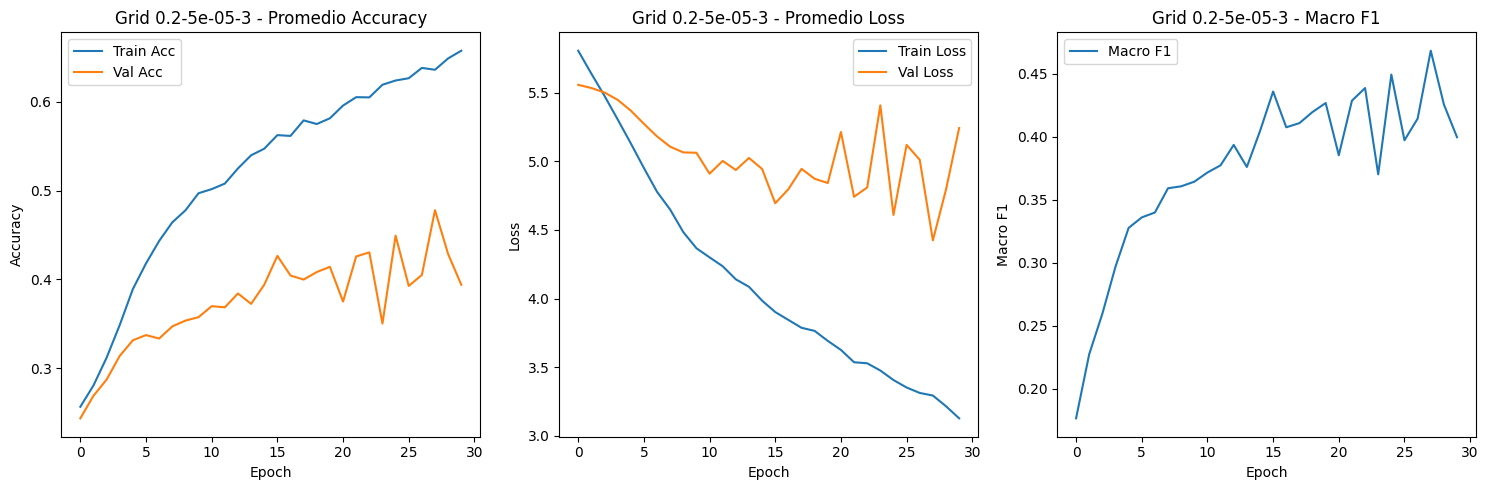


Métricas en validación (media y std):
accuracy     0.393880
precision    0.461009
recall       0.457335
f1           0.399605
dtype: float64
accuracy     0.083056
precision    0.023819
recall       0.056538
f1           0.081124
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)

>>> Entrenando con dropout=0.2, lr=0.0001, folds=3

--- Procesando Fold 1/3 ---
Grid 0.2-0.0001-3, Fold 1, Epoch 1 | Train Acc: 0.328 | Val Acc: 0.389 | MacroF1: 0.353
Grid 0.2-0.0001-3, Fold 1, Epoch 2 | Train Acc: 0.366 | Val Acc: 0.430 | MacroF1: 0.429
Grid 0.2-0.0001-3, Fold 1, Epoch 3 | Train Acc: 0.409 | Val Acc: 0.453 | MacroF1: 0.461
Grid 0.2-0.0001-3, Fold 1, Epoch 4 | Train Acc: 0.459 | Val Acc: 0.426 | MacroF1: 0.441
Grid 0.2-0.0001-3, Fold 1, Epoch 5 | Train Acc: 0.479 | Val Acc: 0.416 | MacroF1: 0.434
Grid 0.2-0.0001-3, Fold 1, Epoch 6 | Train Acc: 0.500 | Val Acc: 0.348 | MacroF1: 0.367
Grid 0.2-0.0001-3, Fold 1, Epoc

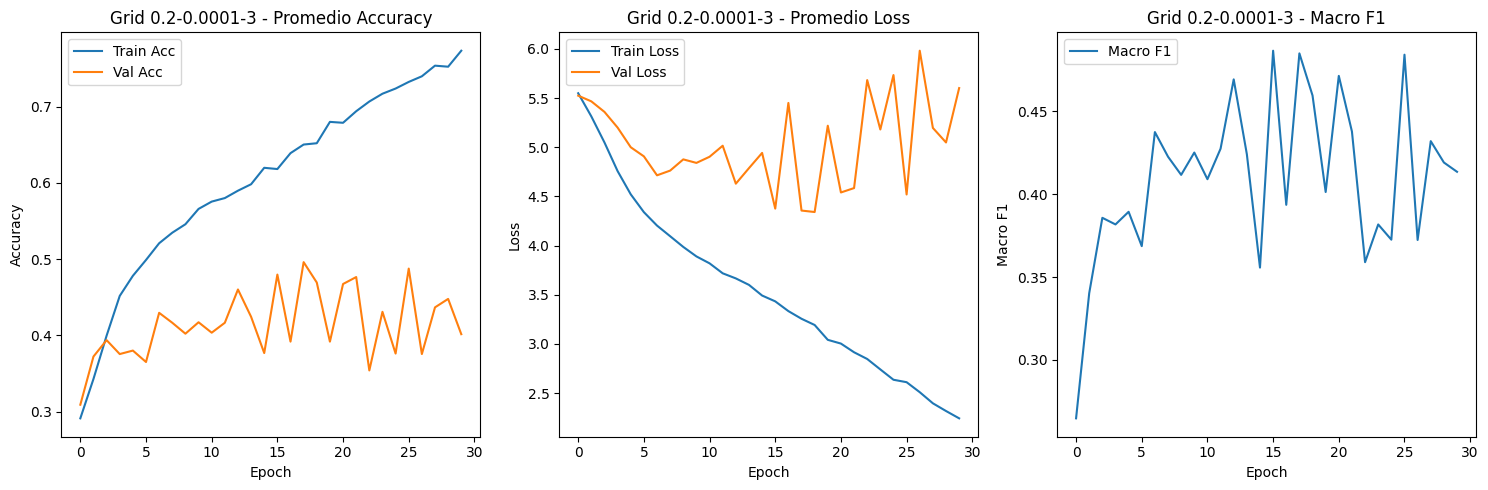


Métricas en validación (media y std):
accuracy     0.401693
precision    0.456042
recall       0.464812
f1           0.413526
dtype: float64
accuracy     0.083696
precision    0.021020
recall       0.027353
f1           0.075726
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)

>>> Entrenando con dropout=0.4, lr=2e-05, folds=3

--- Procesando Fold 1/3 ---
Grid 0.4-2e-05-3, Fold 1, Epoch 1 | Train Acc: 0.293 | Val Acc: 0.311 | MacroF1: 0.220
Grid 0.4-2e-05-3, Fold 1, Epoch 2 | Train Acc: 0.284 | Val Acc: 0.279 | MacroF1: 0.235
Grid 0.4-2e-05-3, Fold 1, Epoch 3 | Train Acc: 0.289 | Val Acc: 0.281 | MacroF1: 0.272
Grid 0.4-2e-05-3, Fold 1, Epoch 4 | Train Acc: 0.310 | Val Acc: 0.246 | MacroF1: 0.252
Grid 0.4-2e-05-3, Fold 1, Epoch 5 | Train Acc: 0.311 | Val Acc: 0.236 | MacroF1: 0.244
Grid 0.4-2e-05-3, Fold 1, Epoch 6 | Train Acc: 0.321 | Val Acc: 0.248 | MacroF1: 0.260
Grid 0.4-2e-05-3, Fold 1, Epoch 7 | Tr

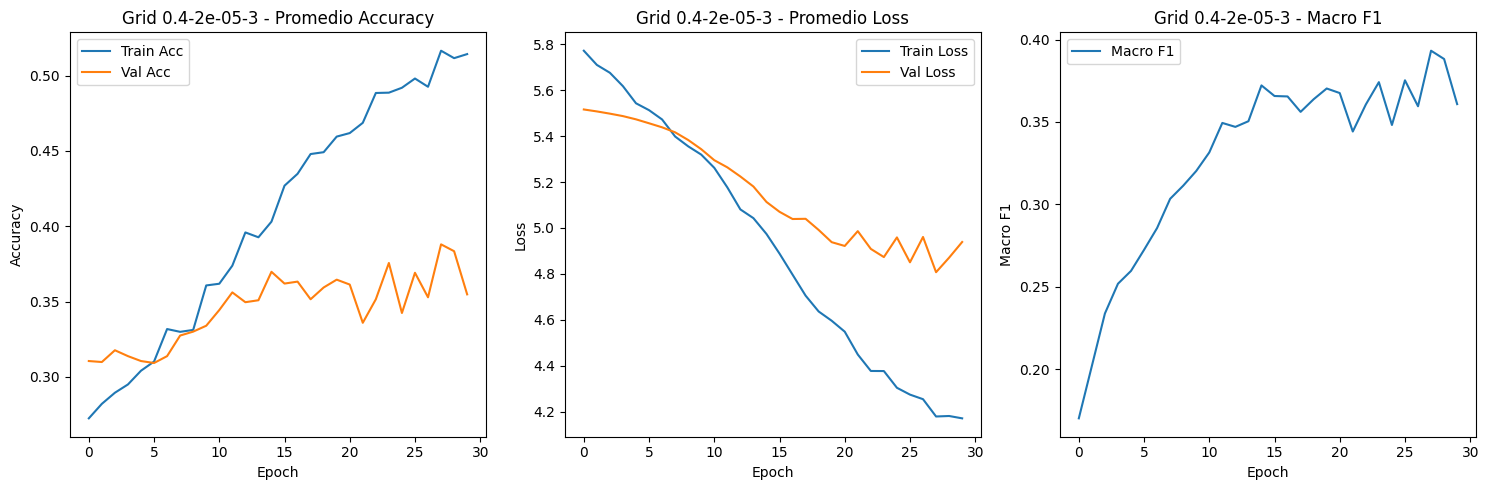


Métricas en validación (media y std):
accuracy     0.354818
precision    0.436684
recall       0.472398
f1           0.360846
dtype: float64
accuracy     0.043949
precision    0.009451
recall       0.020937
f1           0.050278
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)

>>> Entrenando con dropout=0.4, lr=5e-05, folds=3

--- Procesando Fold 1/3 ---
Grid 0.4-5e-05-3, Fold 1, Epoch 1 | Train Acc: 0.258 | Val Acc: 0.324 | MacroF1: 0.256
Grid 0.4-5e-05-3, Fold 1, Epoch 2 | Train Acc: 0.297 | Val Acc: 0.311 | MacroF1: 0.287
Grid 0.4-5e-05-3, Fold 1, Epoch 3 | Train Acc: 0.285 | Val Acc: 0.322 | MacroF1: 0.318
Grid 0.4-5e-05-3, Fold 1, Epoch 4 | Train Acc: 0.328 | Val Acc: 0.324 | MacroF1: 0.335
Grid 0.4-5e-05-3, Fold 1, Epoch 5 | Train Acc: 0.338 | Val Acc: 0.334 | MacroF1: 0.342
Grid 0.4-5e-05-3, Fold 1, Epoch 6 | Train Acc: 0.351 | Val Acc: 0.359 | MacroF1: 0.351
Grid 0.4-5e-05-3, Fold 1, Epoch 7 | Tr

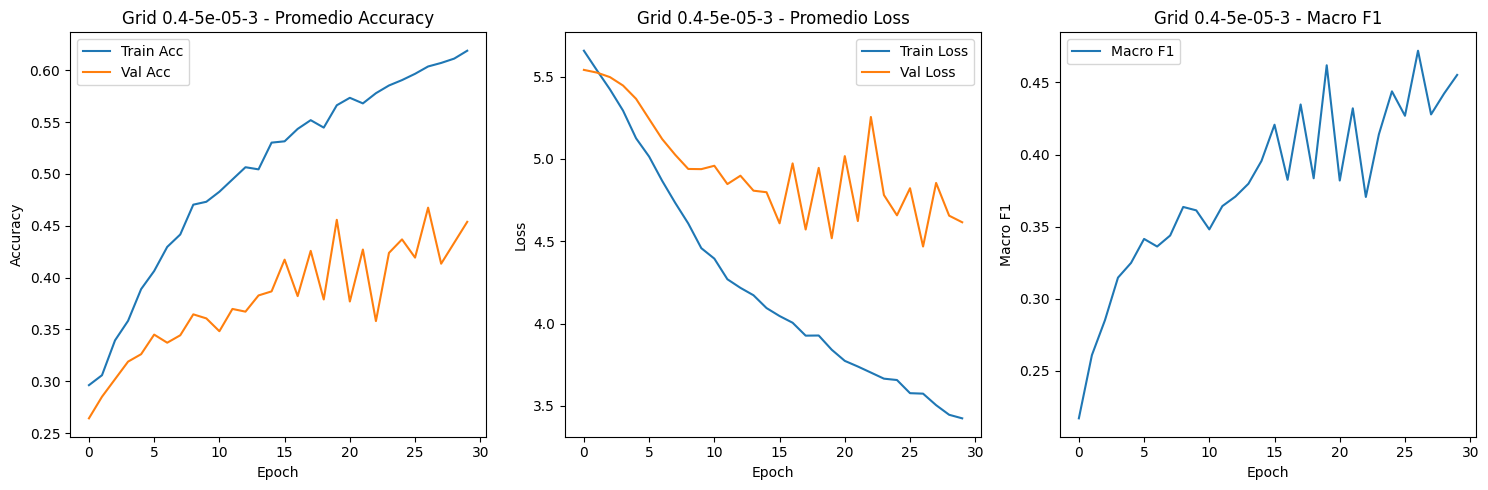


Métricas en validación (media y std):
accuracy     0.453776
precision    0.495824
recall       0.480075
f1           0.455170
dtype: float64
accuracy     0.064905
precision    0.013728
recall       0.037765
f1           0.057587
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)

>>> Entrenando con dropout=0.4, lr=0.0001, folds=3

--- Procesando Fold 1/3 ---
Grid 0.4-0.0001-3, Fold 1, Epoch 1 | Train Acc: 0.247 | Val Acc: 0.309 | MacroF1: 0.205
Grid 0.4-0.0001-3, Fold 1, Epoch 2 | Train Acc: 0.306 | Val Acc: 0.316 | MacroF1: 0.257
Grid 0.4-0.0001-3, Fold 1, Epoch 3 | Train Acc: 0.360 | Val Acc: 0.348 | MacroF1: 0.303
Grid 0.4-0.0001-3, Fold 1, Epoch 4 | Train Acc: 0.399 | Val Acc: 0.385 | MacroF1: 0.361
Grid 0.4-0.0001-3, Fold 1, Epoch 5 | Train Acc: 0.434 | Val Acc: 0.408 | MacroF1: 0.404
Grid 0.4-0.0001-3, Fold 1, Epoch 6 | Train Acc: 0.474 | Val Acc: 0.441 | MacroF1: 0.453
Grid 0.4-0.0001-3, Fold 1, Epoc

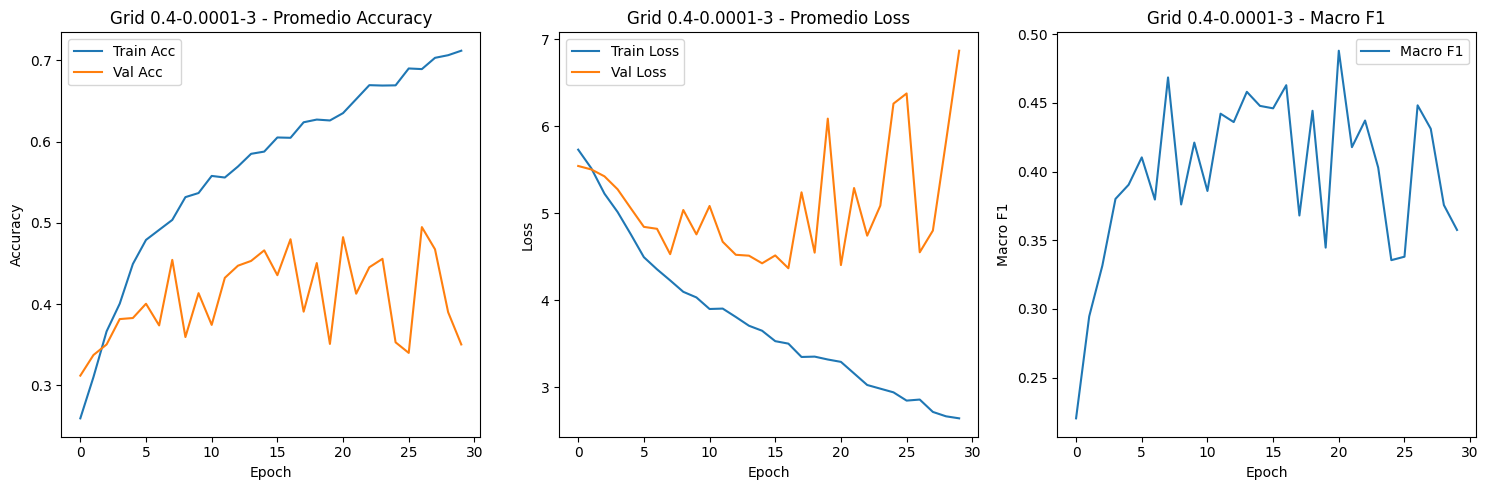


Métricas en validación (media y std):
accuracy     0.350260
precision    0.457093
recall       0.432857
f1           0.357462
dtype: float64
accuracy     0.113371
precision    0.045611
recall       0.052464
f1           0.113739
dtype: float64
fold_probs_test shape: (3, 384, 4)
ensemble_probs shape: (384, 4)
ensemble_pred shape: (384,)
y_test shape: (384,)


In [5]:
# ========================== #
# 4. Entrenamiento KFold Seguro y Ensemble
# ========================== #
resultados_grid = []
ensemble_preds_test = []
ensemble_probs_test = []
histories_allgrids = []

X_features_test_df = None
test_loader = None
feature_columns = None
scaler_global = None

# for dropout, lr, n_splits in product(dropout_grid, learning_rate_grid, n_splits_grid):
#     print(f"\n>>> Entrenando con dropout={dropout}, lr={lr}, folds={n_splits}")
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     histories_folds_grid = []
#     metrics_val_folds = []
#     fold_probs_test = []
#     fold_preds_test = []

#     # Centroides por clase solo con train
#     class_centroids = calcular_centroides_por_clase(X_text_train, y_train, tokenizer, model_bert, device)

#     for fold, (train_index, val_index) in enumerate(kf.split(X_text_train)):
#         print(f"\n--- Procesando Fold {fold+1}/{n_splits} ---")
#         X_fold_train_text = X_text_train.iloc[train_index].tolist()
#         X_fold_val_text   = X_text_train.iloc[val_index].tolist()
#         y_fold_train = pd.Series(y_train).iloc[train_index].reset_index(drop=True)
#         y_fold_val   = pd.Series(y_train).iloc[val_index].reset_index(drop=True)

#         # Embeddings y features SOLO del fold (lingüísticas + distancias)
#         features_train_dicts = [
#             {**extraer_caracteristicas_avanzadas(text, tokenizer, model_bert, device),
#              **agregar_distancia_a_centroides(text, tokenizer, model_bert, device, class_centroids)}
#             for text in X_fold_train_text
#         ]
#         X_fold_train_feats = pd.DataFrame(features_train_dicts)
#         features_val_dicts = [
#             {**extraer_caracteristicas_avanzadas(text, tokenizer, model_bert, device),
#              **agregar_distancia_a_centroides(text, tokenizer, model_bert, device, class_centroids)}
#             for text in X_fold_val_text
#         ]
#         X_fold_val_feats = pd.DataFrame(features_val_dicts)

#         # TF-IDF
#         tfidf_fold = TfidfVectorizer(max_features=5000)
#         tfidf_fold.fit(X_fold_train_text)
#         X_fold_train_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_train_text).mean(axis=1).A1
#         X_fold_val_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_val_text).mean(axis=1).A1

#         # Alineación y normalización
#         feature_columns = X_fold_train_feats.columns.tolist()
#         X_fold_train_feats = X_fold_train_feats[feature_columns]
#         X_fold_val_feats   = X_fold_val_feats[feature_columns]
#         scaler_fold = StandardScaler()
#         scaler_fold.fit(X_fold_train_feats)
#         X_fold_train_feats = pd.DataFrame(scaler_fold.transform(X_fold_train_feats), columns=feature_columns)
#         X_fold_val_feats   = pd.DataFrame(scaler_fold.transform(X_fold_val_feats),   columns=feature_columns)
#         n_linguistic_features = X_fold_train_feats.shape[1]

#         # Tokenización y DataLoader
#         train_encodings = tokenizar_datos(X_fold_train_text, tokenizer)
#         val_encodings = tokenizar_datos(X_fold_val_text, tokenizer)
#         train_dataset = TextDataset(train_encodings, X_fold_train_feats, y_fold_train)
#         val_dataset = TextDataset(val_encodings, X_fold_val_feats, y_fold_val)
#         train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
#         val_loader = DataLoader(val_dataset, batch_size=128)

#         # Modelo, SOLO las últimas capas descongeladas (último encoder BERT)
#         model = BiLSTM_CNN_Text_Classifier(
#             bert_model=model_bert, lstm_hidden_dim=128, n_filters=50, filter_sizes=[2,3,4],
#             output_dim=len(label_encoder.classes_), dropout=dropout, n_linguistic_features=n_linguistic_features
#         ).to(device)
#         for name, param in model.bert.named_parameters():
#             param.requires_grad = False
#         # Descongela últimas 2 capas de BERT
#         for name, param in list(model.bert.encoder.layer.named_parameters())[-2:]:
#             param.requires_grad = True


from imblearn.over_sampling import RandomOverSampler

for dropout, lr, n_splits in product(dropout_grid, learning_rate_grid, n_splits_grid):
    print(f"\n>>> Entrenando con dropout={dropout}, lr={lr}, folds={n_splits}")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    histories_folds_grid = []
    metrics_val_folds = []
    fold_probs_test = []
    fold_preds_test = []

    # Centroides por clase solo con train
    class_centroids = calcular_centroides_por_clase(X_text_train, y_train, tokenizer, model_bert, device)

    for fold, (train_index, val_index) in enumerate(kf.split(X_text_train)):
        print(f"\n--- Procesando Fold {fold+1}/{n_splits} ---")
        X_fold_train_text = X_text_train.iloc[train_index].tolist()
        y_fold_train = pd.Series(y_train).iloc[train_index].reset_index(drop=True)

        # Oversampling SOLO en clases minoritarias
        class_names = list(label_encoder.classes_)
        minority_names = ['Alto', 'Bajo']
        minority_indices = [i for i, name in enumerate(class_names) if name in minority_names]
        present_indices = [idx for idx in minority_indices if idx in set(y_fold_train)]
        if len(present_indices) > 0:
            y_train_counts = Counter(y_fold_train)
            max_count = max([y_train_counts[idx] for idx in y_train_counts])
            sampling_strategy = {idx: max_count for idx in present_indices}
            oversampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
            X_fold_train_text_overs, y_fold_train_overs = oversampler.fit_resample(
                pd.DataFrame({'text': X_fold_train_text}), y_fold_train
            )
            X_fold_train_text = X_fold_train_text_overs['text'].tolist()
            y_fold_train = y_fold_train_overs.reset_index(drop=True)

        # Features lingüísticas + distancias
        features_train_dicts = [
            {**extraer_caracteristicas_avanzadas(text, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(text, tokenizer, model_bert, device, class_centroids)}
            for text in X_fold_train_text
        ]
        X_fold_train_feats = pd.DataFrame(features_train_dicts)

        # Features de validación (sin oversampling)
        X_fold_val_text = X_text_train.iloc[val_index].tolist()
        y_fold_val = pd.Series(y_train).iloc[val_index].reset_index(drop=True)
        features_val_dicts = [
            {**extraer_caracteristicas_avanzadas(text, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(text, tokenizer, model_bert, device, class_centroids)}
            for text in X_fold_val_text
        ]
        X_fold_val_feats = pd.DataFrame(features_val_dicts)

        # TF-IDF
        tfidf_fold = TfidfVectorizer(max_features=5000)
        tfidf_fold.fit(X_fold_train_text)
        X_fold_train_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_train_text).mean(axis=1).A1
        X_fold_val_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_val_text).mean(axis=1).A1

        # Análisis de redundancia/correlación SOLO en train
        corr_matrix = X_fold_train_feats.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
        X_fold_train_feats.drop(columns=to_drop, inplace=True)
        X_fold_val_feats.drop(columns=to_drop, inplace=True)

        # Alineación y normalización
        feature_columns = X_fold_train_feats.columns.tolist()
        X_fold_train_feats = X_fold_train_feats[feature_columns]
        X_fold_val_feats = X_fold_val_feats[feature_columns]
        scaler_fold = StandardScaler()
        scaler_fold.fit(X_fold_train_feats)
        X_fold_train_feats = pd.DataFrame(scaler_fold.transform(X_fold_train_feats), columns=feature_columns)
        X_fold_val_feats = pd.DataFrame(scaler_fold.transform(X_fold_val_feats), columns=feature_columns)
        n_linguistic_features = len(feature_columns)

        # Tokenización y DataLoader
        train_encodings = tokenizar_datos(X_fold_train_text, tokenizer)
        val_encodings = tokenizar_datos(X_fold_val_text, tokenizer)
        train_dataset = TextDataset(train_encodings, X_fold_train_feats, y_fold_train)
        val_dataset = TextDataset(val_encodings, X_fold_val_feats, y_fold_val)
        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=256)

        # Modelo, descongela últimas 4 capas de BERT
        model = BiLSTM_CNN_Text_Classifier(
            bert_model=model_bert, lstm_hidden_dim=128, n_filters=50, filter_sizes=[2,3,4],
            output_dim=len(label_encoder.classes_), dropout=dropout, n_linguistic_features=n_linguistic_features
        ).to(device)
        for name, param in model.bert.named_parameters():
            param.requires_grad = False
        for name, param in list(model.bert.encoder.layer.named_parameters())[-4:]:
            param.requires_grad = True

        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        class_counts = Counter(y_fold_train)
        total_count = sum(class_counts.values())
        class_weights = {cls: total_count / count for cls, count in class_counts.items()}
        weights = torch.tensor([class_weights[i] for i in range(len(class_counts))], dtype=torch.float).to(device)
        class FocalLoss(nn.Module):
            def __init__(self, alpha=1, gamma=1.5, weight=None, reduction='mean'):
                super().__init__()
                self.alpha = alpha
                self.gamma = gamma
                self.weight = weight
                self.reduction = reduction
            def forward(self, inputs, targets):
                ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(inputs, targets)
                pt = torch.exp(-ce_loss)
                focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
                if self.reduction == 'mean':
                    return focal_loss.mean()
                elif self.reduction == 'sum':
                    return focal_loss.sum()
                else:
                    return focal_loss
        loss_fn = FocalLoss(weight=weights)

        def entrenar_modelo(model, loader, optimizer):
            model.train()
            total_loss, total_correct = 0, 0
            for batch in loader:
                optimizer.zero_grad()
                inputs = {key: val.to(device) for key, val in batch.items() if key not in ['features', 'labels']}
                features = batch['features'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], features=features)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                preds = outputs.argmax(dim=1)
                total_correct += (preds == labels).sum().item()
            return total_loss / len(loader), total_correct / len(loader.dataset)
        def evaluar_modelo(model, loader):
            model.eval()
            true_labels, predictions = [], []
            with torch.no_grad():
                for batch in loader:
                    inputs = {key: val.to(device) for key, val in batch.items() if key not in ['features', 'labels']}
                    features = batch['features'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], features=features)
                    preds = outputs.argmax(dim=1)
                    true_labels.extend(labels.cpu().numpy())
                    predictions.extend(preds.cpu().numpy())
            return true_labels, predictions

        fold_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'val_f1': []}
        for epoch in range(EPOCHS):
            train_loss, train_acc = entrenar_modelo(model, train_loader, optimizer)
            true_labels_val, predictions_val = evaluar_modelo(model, val_loader)
            val_accuracy = accuracy_score(true_labels_val, predictions_val)
            val_f1 = f1_score(true_labels_val, predictions_val, average='macro', zero_division=0)
            model.eval()
            total_val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    inputs = {key: val.to(device) for key, val in batch.items() if key not in ['features', 'labels']}
                    features = batch['features'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], features=features)
                    loss = loss_fn(outputs, labels)
                    total_val_loss += loss.item()
            val_loss = total_val_loss / len(val_loader)
            fold_history['train_acc'].append(train_acc)
            fold_history['val_acc'].append(val_accuracy)
            fold_history['val_f1'].append(val_f1)
            fold_history['train_loss'].append(train_loss)
            fold_history['val_loss'].append(val_loss)
            print(f"Grid {dropout}-{lr}-{n_splits}, Fold {fold+1}, Epoch {epoch+1} | Train Acc: {train_acc:.3f} | Val Acc: {val_accuracy:.3f} | MacroF1: {val_f1:.3f}")

        metrics_val_folds.append({
            "accuracy": accuracy_score(true_labels_val, predictions_val),
            "precision": precision_score(true_labels_val, predictions_val, average='macro', zero_division=0),
            "recall": recall_score(true_labels_val, predictions_val, average='macro', zero_division=0),
            "f1": f1_score(true_labels_val, predictions_val, average='macro', zero_division=0)
        })
        histories_folds_grid.append(fold_history)

        # ========== BLOQUE DE FEATURES DE TEST PARA ENSEMBLE ==========

        print(f"Procesando features de test para ensemble en Fold {fold+1}...")

        features_test_dicts = [
            {**extraer_caracteristicas_avanzadas(text, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(text, tokenizer, model_bert, device, class_centroids)}
            for text in X_text_test.tolist()
        ]
        X_features_test_df = pd.DataFrame(features_test_dicts)
        X_features_test_df["tfidf_avg"] = tfidf_fold.transform(X_text_test.tolist()).mean(axis=1).A1

        # Alineación estricta (sólo columnas del fold actual)
        for col in feature_columns:
            if col not in X_features_test_df.columns:
                X_features_test_df[col] = 0.0
        X_features_test_df = X_features_test_df[feature_columns]
        assert list(X_features_test_df.columns) == feature_columns, (
            f"Columnas en test y train no coinciden en fold {fold+1}:\nTest: {list(X_features_test_df.columns)}\nTrain: {feature_columns}"
        )

        X_features_test_df = pd.DataFrame(scaler_fold.transform(X_features_test_df), columns=feature_columns)

        test_encodings = tokenizar_datos(X_text_test.tolist(), tokenizer)
        test_dataset = TextDataset(test_encodings, X_features_test_df, pd.Series(y_test).reset_index(drop=True))
        test_loader = DataLoader(test_dataset, batch_size=256)

        # ========== Predicciones en test ==========
        def get_probs(model, loader):
            model.eval()
            probs = []
            with torch.no_grad():
                for batch in loader:
                    inputs = {key: val.to(device) for key, val in batch.items() if key not in ['features', 'labels']}
                    features = batch['features'].to(device)
                    outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], features=features)
                    out_probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    if out_probs.ndim == 1:
                        out_probs = out_probs.reshape(-1, 1)
                    probs.append(out_probs)
            probs_concat = np.concatenate(probs)
            if probs_concat.ndim == 1:
                probs_concat = probs_concat.reshape(-1, 1)
            return probs_concat
        
        probs_test = get_probs(model, test_loader)
        fold_probs_test.append(probs_test)

    # ========== Resultados fold promedio ==========
    avg_train_acc = np.mean([h['train_acc'] for h in histories_folds_grid], axis=0)
    avg_val_acc   = np.mean([h['val_acc'] for h in histories_folds_grid], axis=0)
    avg_train_loss = np.mean([h['train_loss'] for h in histories_folds_grid], axis=0)
    avg_val_loss   = np.mean([h['val_loss'] for h in histories_folds_grid], axis=0)
    avg_val_f1     = np.mean([h['val_f1'] for h in histories_folds_grid], axis=0)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.plot(avg_train_acc, label='Train Acc')
    plt.plot(avg_val_acc, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Promedio Accuracy')
    plt.legend()
    plt.subplot(1,3,2)
    plt.plot(avg_train_loss, label='Train Loss')
    plt.plot(avg_val_loss, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Promedio Loss')
    plt.legend()
    plt.subplot(1,3,3)
    plt.plot(avg_val_f1, label='Macro F1')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Macro F1')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if metrics_val_folds:
        df_metrics_val = pd.DataFrame(metrics_val_folds)
        print("\nMétricas en validación (media y std):")
        print(df_metrics_val.mean())
        print(df_metrics_val.std())
    
    # ============= ENSEMBLE FINAL =============
    fold_probs_test = np.array(fold_probs_test)
    print("fold_probs_test shape:", fold_probs_test.shape)
    # Debe ser: (num_folds, num_muestras, num_clases)

    if fold_probs_test.ndim == 2:  # Solo un fold o una clase
        # (num_muestras, num_clases) o (num_muestras,). Fuerza a (1, num_muestras, num_clases)
        if fold_probs_test.shape[1] > 1:
            fold_probs_test = fold_probs_test[None, :, :]
        else:
            fold_probs_test = fold_probs_test[None, :, None]
    elif fold_probs_test.ndim == 1:
        fold_probs_test = fold_probs_test[None, :, None]

    # Calcula el promedio sobre folds (primer eje)
    ensemble_probs = np.mean(fold_probs_test, axis=0)
    print("ensemble_probs shape:", ensemble_probs.shape)
    if ensemble_probs.ndim == 1:
        # Solo una clase, fuerza a (num_muestras, 1)
        ensemble_probs = ensemble_probs.reshape(-1, 1)

    ensemble_pred = np.argmax(ensemble_probs, axis=1)
    print("ensemble_pred shape:", ensemble_pred.shape)
    print("y_test shape:", np.shape(y_test))

    # Check de dimensiones antes de calcular métricas
    assert len(y_test) == len(ensemble_pred), (
        f"Inconsistencia de longitud: y_test={len(y_test)}, ensemble_pred={len(ensemble_pred)}"
    )
    acc_ensemble = accuracy_score(y_test, ensemble_pred)
    try:
        auc_ensemble = roc_auc_score(y_test, ensemble_probs, multi_class="ovr", average='macro')
    except:
        auc_ensemble = np.nan
    macrof1_ensemble = f1_score(y_test, ensemble_pred, average='macro', zero_division=0)
    resultados_grid.append({
        "dropout": dropout,
        "learning_rate": lr,
        "n_splits": n_splits,
        "ensemble_accuracy_test": acc_ensemble,
        "ensemble_auc_test": auc_ensemble,
        "ensemble_macro_f1": macrof1_ensemble,
        "val_acc_mean": df_metrics_val["accuracy"].mean(),
        "val_acc_std": df_metrics_val["accuracy"].std()
    })
    ensemble_preds_test.append(ensemble_pred)
    ensemble_probs_test.append(ensemble_probs)
    histories_allgrids.append(histories_folds_grid)



In [6]:
# ========== Reporte final ========== #
df_resultados_grid = pd.DataFrame(resultados_grid)
print(df_resultados_grid.sort_values("ensemble_macro_f1", ascending=False))
print("\nVersión para LaTeX:")
print(df_resultados_grid.sort_values("ensemble_macro_f1", ascending=False).to_latex(index=False, float_format="%.4f"))



   dropout  learning_rate  n_splits  ensemble_accuracy_test  \
4      0.4        0.00005         3                0.523438   
1      0.2        0.00005         3                0.507812   
2      0.2        0.00010         3                0.460938   
3      0.4        0.00002         3                0.434896   
5      0.4        0.00010         3                0.338542   
0      0.2        0.00002         3                0.268229   

   ensemble_auc_test  ensemble_macro_f1  val_acc_mean  val_acc_std  
4           0.768809           0.485031      0.453776     0.064905  
1           0.768226           0.471258      0.393880     0.083056  
2           0.755737           0.435910      0.401693     0.083696  
3           0.743207           0.385724      0.354818     0.043949  
5           0.744197           0.332052      0.350260     0.113371  
0           0.746680           0.211246      0.371094     0.005859  

Versión para LaTeX:
\begin{tabular}{rrrrrrrr}
\toprule
dropout & learning_


Mejor configuración de ensemble: {'dropout': 0.4, 'learning_rate': 5e-05, 'n_splits': 3, 'ensemble_accuracy_test': 0.5234375, 'ensemble_auc_test': np.float64(0.7688086016959049), 'ensemble_macro_f1': np.float64(0.48503072529627644), 'val_acc_mean': np.float64(0.4537760416666667), 'val_acc_std': np.float64(0.0649052952154538)}
=== Reporte de Clasificación (TEST, ensemble) ===
              precision    recall  f1-score   support

        Alto       0.38      0.20      0.26        56
        Bajo       0.55      0.68      0.61        62
  Medio alto       0.52      0.66      0.58       137
  Medio bajo       0.55      0.44      0.49       129

    accuracy                           0.52       384
   macro avg       0.50      0.49      0.49       384
weighted avg       0.51      0.52      0.51       384



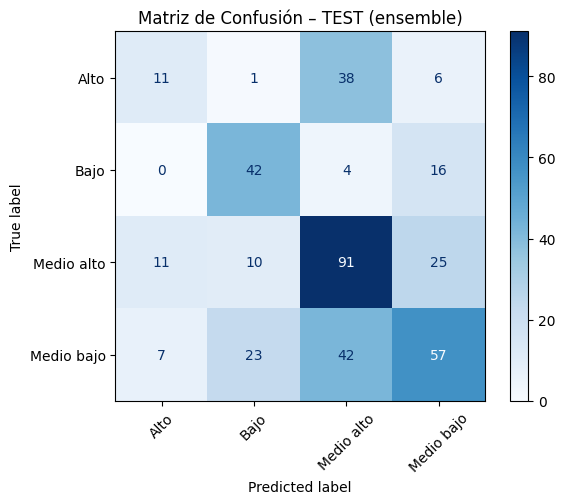

In [7]:
# ========== EVALUACIÓN FINAL Y CURVAS ==========
best_idx = np.argmax([res["ensemble_macro_f1"] for res in resultados_grid])
best_config = resultados_grid[best_idx]
best_preds  = ensemble_preds_test[best_idx]
best_probs  = ensemble_probs_test[best_idx]

print(f"\nMejor configuración de ensemble: {best_config}")
print("=== Reporte de Clasificación (TEST, ensemble) ===")
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))

cm_ensemble = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm_ensemble, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión – TEST (ensemble)")
plt.show()



In [8]:
# ===== AUC por clase ===== #
auc_dict = {}
for i, class_name in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score((y_test == i).astype(int), best_probs[:, i])
    auc_dict[class_name] = auc_score

# Tabla integrada
results_table = []
class_report = classification_report(y_test, best_preds, target_names=label_encoder.classes_, output_dict=True)
for cls in label_encoder.classes_:
    results_table.append({
        "model": "BETO test",
        "class": cls,
        "precision": class_report[cls]['precision'],
        "recall": class_report[cls]['recall'],
        "f1": class_report[cls]['f1-score'],
        "support": class_report[cls]['support'],
        "auc": auc_dict[cls]
    })
df_auc_classes = pd.DataFrame(results_table)
print(df_auc_classes)



       model       class  precision    recall        f1  support       auc
0  BETO test        Alto   0.379310  0.196429  0.258824     56.0  0.793064
1  BETO test        Bajo   0.552632  0.677419  0.608696     62.0  0.895963
2  BETO test  Medio alto   0.520000  0.664234  0.583333    137.0  0.697775
3  BETO test  Medio bajo   0.548077  0.441860  0.489270    129.0  0.688433


In [9]:
# ======= Memoria ========
def liberar_memoria(model, optimizer=None):
    model.to("cpu")
    if optimizer:
        del optimizer
    torch.cuda.empty_cache()
    gc.collect()
    print("Memoria de GPU liberada.")

liberar_memoria(model=model, optimizer=optimizer)


"""
             precision    recall  f1-score   support

        Alto       0.30      0.64      0.40        56
        Bajo       0.60      0.61      0.61        62
  Medio alto       0.46      0.37      0.41       137
  Medio bajo       0.52      0.36      0.42       129

    accuracy                           0.45       384
   macro avg       0.47      0.50      0.46       384
weighted avg       0.48      0.45      0.45       384

       model       class  precision    recall        f1  support       auc
0  BETO test        Alto   0.295082  0.642857  0.404494     56.0  0.767694
1  BETO test        Bajo   0.603175  0.612903  0.608000     62.0  0.891354
2  BETO test  Medio alto   0.459459  0.372263  0.411290    137.0  0.706729
3  BETO test  Medio bajo   0.522727  0.356589  0.423963    129.0  0.698434
Memoria de GPU liberada.
"""

Memoria de GPU liberada.


'\n             precision    recall  f1-score   support\n\n        Alto       0.30      0.64      0.40        56\n        Bajo       0.60      0.61      0.61        62\n  Medio alto       0.46      0.37      0.41       137\n  Medio bajo       0.52      0.36      0.42       129\n\n    accuracy                           0.45       384\n   macro avg       0.47      0.50      0.46       384\nweighted avg       0.48      0.45      0.45       384\n\n       model       class  precision    recall        f1  support       auc\n0  BETO test        Alto   0.295082  0.642857  0.404494     56.0  0.767694\n1  BETO test        Bajo   0.603175  0.612903  0.608000     62.0  0.891354\n2  BETO test  Medio alto   0.459459  0.372263  0.411290    137.0  0.706729\n3  BETO test  Medio bajo   0.522727  0.356589  0.423963    129.0  0.698434\nMemoria de GPU liberada.\n'